### Setup and Imports

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

### Data Ingestion

In [2]:
# Rounding the dates to month end, the last 4 Teasury notes are off

df = pd.read_excel("../Data/treasury_quotes_2025-11-28.xlsx", sheet_name="selected quotes")
df['quote date'] = df['quote date'] + pd.offsets.MonthEnd(0)
df['maturity date'] = df['maturity date'] + pd.offsets.MonthEnd(0)

## 1 Discounts Rates

In [3]:
max_date = df['maturity date'].max()
date_index = pd.date_range(start = "2026-05-31", end=max_date, freq=pd.offsets.MonthEnd(6)).round(freq='D')
date_index
cashflow = pd.DataFrame(columns = date_index, index = df['KYTREASNO'])
cashflow

,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:

for index, note in df.iterrows():
    maturity = note['maturity date']
    coupon = note['cpn rate'] / 100
    par = 100
    freq = 2
    issue_date = ['issue date']
    payment_dates = pd.date_range(start='2025-11-30', end=maturity, freq=pd.offsets.MonthEnd(6)).round(freq='D')
    
    for pay_date in payment_dates:
        if pay_date in cashflow.columns:
            if pay_date == maturity:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (1 + (coupon / freq))
            else:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (coupon / freq)

cashflow.fillna(0, inplace=True)
cashflow

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_17560/3518927822.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cashflow.fillna(0, inplace=True)


,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,102.4375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208316,2.1250,102.1250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208399,1.9375,1.9375,101.9375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208484,1.6875,1.6875,1.6875,101.6875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208058,1.8125,1.8125,1.8125,1.8125,101.8125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208145,2.1875,2.1875,2.1875,2.1875,2.1875,102.1875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208229,2.2500,2.2500,2.2500,2.2500,2.2500,2.2500,102.2500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208318,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,102.0625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208401,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,102.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0


### 1.2 Optimization

Solve z in the equation $p = Cz$ 

In [5]:
print("Size of cashflow matrix:", cashflow.shape)

Size of cashflow matrix: (20, 20)


In [6]:
from scipy import linalg

C = np.array(cashflow)
p = np.array(df[['price']])

z = linalg.solve(C, p)
z


array([[0.9813429 ],
       [0.96447159],
       [0.94855058],
       [0.93308752],
       [0.91722537],
       [0.90105047],
       [0.88495417],
       [0.86844763],
       [0.85254463],
       [0.83646536],
       [0.81864008],
       [0.80186849],
       [0.7846308 ],
       [0.76799179],
       [0.75085014],
       [0.73504424],
       [0.71814171],
       [0.70092077],
       [0.68434715],
       [0.66844766]])

### 1.3 Plotting the discount rates and factors

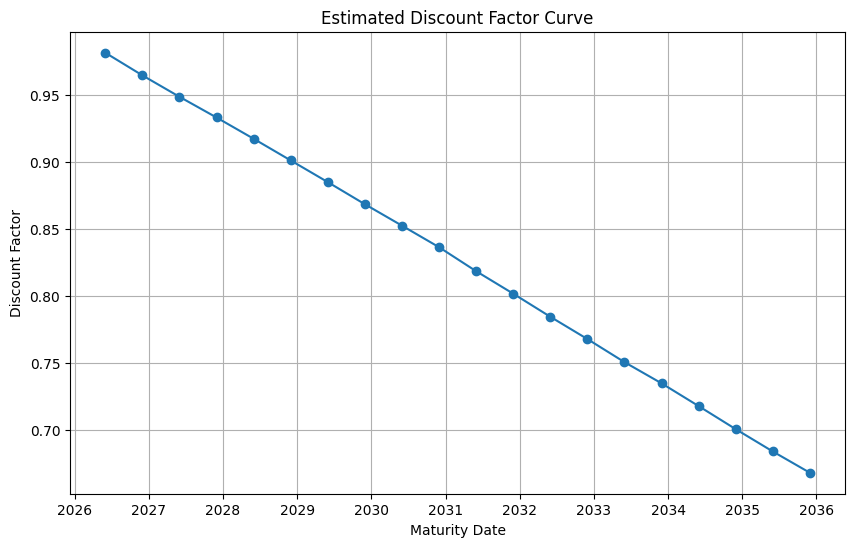

In [7]:
discount_factors = pd.DataFrame(data=z, index=date_index, columns=['Discount Factor'])
figure = plt.figure(figsize=(10,6))
plt.plot(discount_factors.index, discount_factors['Discount Factor'], marker='o')
plt.title('Estimated Discount Factor Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Factor')
plt.grid()
plt.show()

In [16]:
discount_factors

,Discount Factor
2026-05-31,0.981343
2026-11-30,0.964472
2027-05-31,0.948551
2027-11-30,0.933088
2028-05-31,0.917225
2028-11-30,0.901050
2029-05-31,0.884954
2029-11-30,0.868448
2030-05-31,0.852545
2030-11-30,0.836465


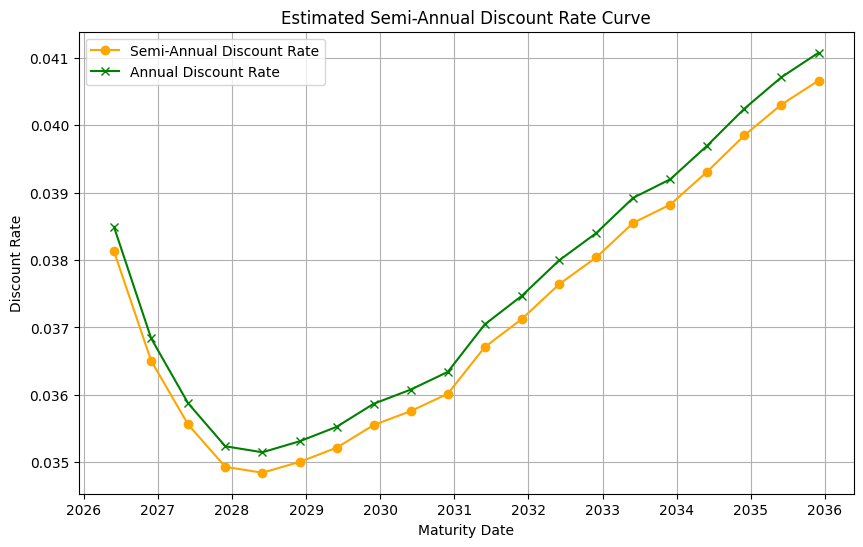

In [23]:

# Time to maturity in years
time_to_maturity = (date_index - pd.Timestamp("2025-11-30")).days / 365

# Annual compounding
annual_discount_rates = (1 / discount_factors['Discount Factor']) ** (1 / time_to_maturity) - 1

# Semi-annual compounding
semi_annual_discount_rates = 2 * ((1 / discount_factors['Discount Factor']) ** (1 / (2 * time_to_maturity)) - 1)

plt.figure(figsize=(10,6))
plt.plot(semi_annual_discount_rates.index, semi_annual_discount_rates, marker='o', color='orange')
plt.plot(annual_discount_rates.index, annual_discount_rates, marker='x', color='green')
plt.title('Estimated Semi-Annual Discount Rate Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Rate')
plt.legend(['Semi-Annual Discount Rate', 'Annual Discount Rate'])
plt.grid()
plt.show()

### 1.4 Curve Fitting With Nelson-Siegel


Payment dates: DatetimeIndex(['2026-05-31', '2026-11-30', '2027-05-31', '2027-11-30',
               '2028-05-31', '2028-11-30', '2029-05-31', '2029-11-30',
               '2030-05-31', '2030-11-30', '2031-05-31', '2031-11-30',
               '2032-05-31', '2032-11-30', '2033-05-31', '2033-11-30',
               '2034-05-31', '2034-11-30', '2035-05-31', '2035-11-30'],
              dtype='datetime64[ns]', freq=None)
Times (years): [0.5037645448323066, 1.0047912388774811, 1.5030800821355237, 2.004106776180698, 2.5051334702258727, 3.0061601642710474, 3.5044490075290895, 4.005475701574264, 4.503764544832307, 5.004791238877481, 5.503080082135524, 6.0041067761806985, 6.505133470225872, 7.006160164271047, 7.5044490075290895, 8.005475701574264, 8.503764544832306, 9.00479123887748, 9.503080082135524, 10.004106776180699]

Initial objective value: 20.316952108192698

First 5 bonds comparison:
Bond 0: Market=100.5263, Initial Model=100.7879
Bond 1: Market=100.5820, Initial Model=100.7909
Bond 2: 

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_17560/514130370.py:61: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(objective, params, method='L-BFGS-B', bounds=bounds,


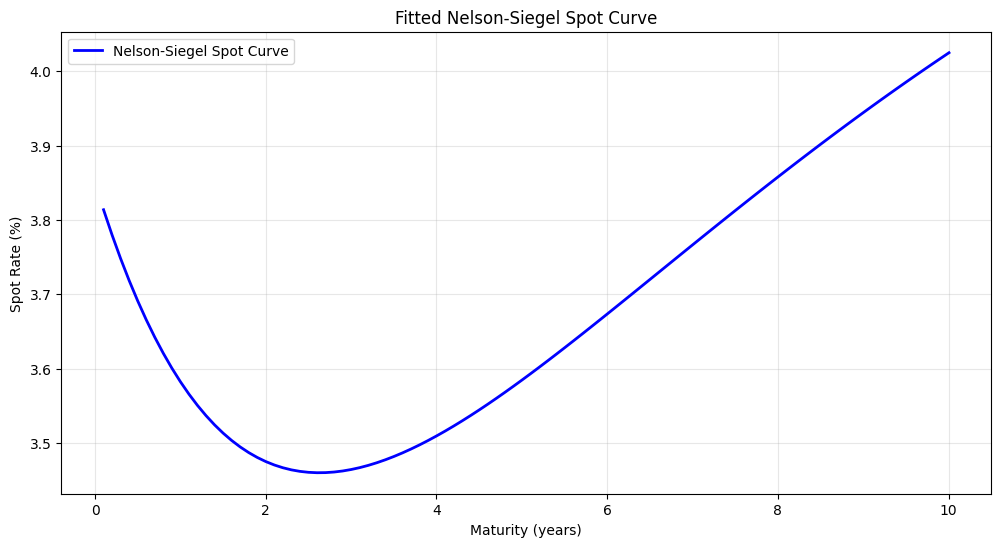


Optimal parameters dictionary: {'theta0': np.float64(0.05081502509546659), 'theta1': np.float64(-0.012312366931586266), 'theta2': np.float64(-0.03190677008065287), 'lambda': np.float64(2.5994335935403825)}


In [15]:
from scipy.optimize import minimize

# Your existing cashflow matrix
cashflow.fillna(0, inplace=True)

# Convert payment dates to time in years from today
today = pd.Timestamp('2025-11-28')  # or pd.Timestamp.today()
payment_dates = cashflow.columns
times_in_years = [(pd.Timestamp(date) - today).days / 365.25 for date in payment_dates]

print("Payment dates:", payment_dates)
print("Times (years):", times_in_years)

# Convert to numpy arrays for optimization
C = cashflow.values  # shape: (n_bonds, n_payment_dates)
market_prices = df['price'].values
times = np.tile(times_in_years, (len(C), 1))  # same times for all bonds

# Nelson-Siegel spot rate formula
def ns_spot_rate(tau, theta0, theta1, theta2, lam):
    if tau <= 0:
        return theta0
    factor1 = (1 - np.exp(-tau/lam)) / (tau/lam)
    factor2 = factor1 - np.exp(-tau/lam)
    return theta0 + theta1 * factor1 + theta2 * factor2

# Calculate model prices for given parameters
def calculate_model_prices(params):
    theta0, theta1, theta2, lam = params
    model_prices = []
    
    for i in range(len(C)):
        price = 0
        for j in range(len(times_in_years)):
            if C[i, j] != 0 and times_in_years[j] > 0:
                spot = ns_spot_rate(times_in_years[j], theta0, theta1, theta2, lam)
                df = np.exp(-spot * times_in_years[j])
                price += C[i, j] * df
        model_prices.append(price)
    
    return np.array(model_prices)

# Objective: minimize squared pricing errors
def objective(params):
    model_prices = calculate_model_prices(params)
    errors = market_prices - model_prices
    return np.sum(errors**2)

# Initial parameter guess: [theta0, theta1, theta2, lambda]
params = np.array([0.04, -0.01, 0.01, 2.0])

# Test with initial parameters
print("\nInitial objective value:", objective(params))
initial_prices = calculate_model_prices(params)
print("\nFirst 5 bonds comparison:")
for i in range(min(5, len(market_prices))):
    print(f"Bond {i}: Market={market_prices[i]:.4f}, Initial Model={initial_prices[i]:.4f}")

# Optimize
bounds = [(0.0, 0.15), (-0.1, 0.1), (-0.1, 0.1), (0.1, 10.0)]
result = minimize(objective, params, method='L-BFGS-B', bounds=bounds, 
                 options={'maxiter': 1000, 'disp': True})

print("\n" + "="*50)
print("Optimization result:")
print("="*50)
print(f"Success: {result.success}")
print(f"Optimal θ₀: {result.x[0]:.6f}")
print(f"Optimal θ₁: {result.x[1]:.6f}")
print(f"Optimal θ₂: {result.x[2]:.6f}")
print(f"Optimal λ: {result.x[3]:.6f}")
print(f"Final SSE: {result.fun:.6f}")

# Check final fit
optimal_prices = calculate_model_prices(result.x)
print("\nFinal price comparison:")
for i in range(len(market_prices)):
    error = market_prices[i] - optimal_prices[i]
    pct_error = (error / market_prices[i]) * 100
    print(f"Bond {df.iloc[i]['KYTREASNO']}: Market={market_prices[i]:.4f}, "
          f"Model={optimal_prices[i]:.4f}, Error={error:.4f} ({pct_error:.2f}%)")

# Calculate RMSE
rmse = np.sqrt(result.fun / len(market_prices))
print(f"\nRMSE: {rmse:.6f}")
print(f"Mean Absolute Error: {np.mean(np.abs(market_prices - optimal_prices)):.6f}")

# Extract and plot the optimal spot curve
optimal_params = result.x
maturities = np.linspace(0.1, max(times_in_years), 100)
spot_rates = [ns_spot_rate(t, *optimal_params) for t in maturities]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(maturities, np.array(spot_rates) * 100, 'b-', linewidth=2, label='Nelson-Siegel Spot Curve')
plt.xlabel('Maturity (years)')
plt.ylabel('Spot Rate (%)')
plt.title('Fitted Nelson-Siegel Spot Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Store the optimal parameters for later use
ns_params = {
    'theta0': result.x[0],
    'theta1': result.x[1],
    'theta2': result.x[2],
    'lambda': result.x[3]
}
print("\nOptimal parameters dictionary:", ns_params)

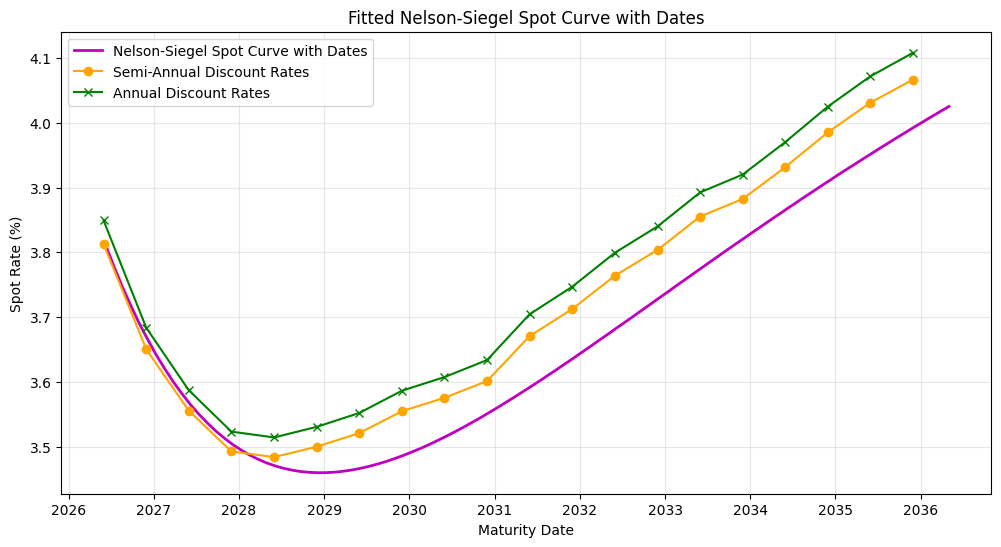

In [51]:
spot_rate_with_dates = pd.DataFrame({
    'Maturity Date': [pd.Timestamp("2026-05-01") + pd.DateOffset(days=int(m * 365.25)) for m in maturities],
    'Spot Rate (%)': np.array(spot_rates) * 100
})


plt.figure(figsize=(12, 6))
plt.plot(spot_rate_with_dates['Maturity Date'], spot_rate_with_dates['Spot Rate (%)'], 'm-', linewidth=2, label='Nelson-Siegel Spot Curve with Dates')
plt.plot(semi_annual_discount_rates.index, semi_annual_discount_rates * 100, marker='o', color='orange', label='Semi-Annual Discount Rates')
plt.plot(annual_discount_rates.index, annual_discount_rates * 100, marker='x', color='green', label='Annual Discount Rates')
plt.xlabel('Maturity Date')
plt.ylabel('Spot Rate (%)')
plt.title('Fitted Nelson-Siegel Spot Curve with Dates')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2 Estimating the Discount Curve with Non Evenly Spaced Data

In [55]:
dt = pd.read_excel("../Data/treasury_quotes_2025-11-28.xlsx", sheet_name="quotes")
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   KYTREASNO         455 non-null    int64         
 1   type              455 non-null    object        
 2   quote date        455 non-null    datetime64[ns]
 3   issue date        455 non-null    datetime64[ns]
 4   maturity date     455 non-null    datetime64[ns]
 5   ttm               455 non-null    float64       
 6   accrual fraction  403 non-null    float64       
 7   cpn rate          455 non-null    float64       
 8   bid               455 non-null    float64       
 9   ask               455 non-null    float64       
 10  price             455 non-null    float64       
 11  accrued int       455 non-null    float64       
 12  dirty price       455 non-null    float64       
 13  ytm               402 non-null    float64       
 14  total size        449 non-

In [56]:
dt = dt[(dt['ytm'] >= 0) & (dt['type'].isin(['note', 'bill', 'bond']))] 
dt

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
0,208422,bill,2025-11-28,2025-08-05,2025-12-02,0.010951,NaN,0.000,99.989146,99.989174,99.989160,0.000000,99.989160,0.009924,2.657700e+11,0.010959
1,208397,bill,2025-11-28,2025-06-05,2025-12-04,0.016427,NaN,0.000,99.967491,99.967574,99.967532,0.000000,99.967532,0.019866,2.514150e+11,0.016438
2,208432,bill,2025-11-28,2025-08-12,2025-12-09,0.030116,NaN,0.000,99.913089,99.913311,99.913200,0.000000,99.913200,0.029043,2.707090e+11,0.030137
3,208410,bill,2025-11-28,2025-06-12,2025-12-11,0.035592,NaN,0.000,99.891417,99.891694,99.891556,0.000000,99.891556,0.030719,2.552590e+11,0.035616
4,207988,note,2025-11-28,2022-12-15,2025-12-15,0.046543,0.907104,4.000,99.998315,99.998711,99.998513,1.814208,101.812721,0.039877,3.999900e+10,0.046575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,208322,bond,2025-11-28,2024-11-15,2054-11-15,28.963723,0.071823,4.500,97.199219,97.257812,97.228516,0.161602,97.390118,0.046760,8.006300e+10,16.261140
451,208362,bond,2025-11-28,2025-02-15,2055-02-15,29.215606,0.570652,4.625,99.246094,99.300781,99.273437,1.319633,100.593071,0.046705,7.990100e+10,16.056723
452,208405,bond,2025-11-28,2025-05-15,2055-05-15,29.459274,0.071823,4.750,101.296875,101.359375,101.328125,0.170580,101.498705,0.046673,8.080300e+10,16.217796
453,208448,bond,2025-11-28,2025-08-15,2055-08-15,29.711157,0.570652,4.750,101.328125,101.390625,101.359375,1.355299,102.714674,0.046650,7.787900e+10,16.100166


### Below functions are imported from Mark's Repo

In [68]:
import datetime


def calc_cashflows(quote_data, filter_maturity_dates=False):
    
    CF = pd.DataFrame(dtype=float, data=0, index=quote_data.index, columns=quote_data['TMATDT'].unique())

    for i in quote_data.index:
        coupon_dates = get_coupon_dates(quote_data.loc[i,'CALDT'],quote_data.loc[i,'TMATDT'])

        if coupon_dates is not None:
            CF.loc[i,coupon_dates] = quote_data.loc[i,'TCOUPRT']/2

        CF.loc[i,quote_data.loc[i,'TMATDT']] += 100


    CF = CF.fillna(0).sort_index(axis=1)
    CF.drop(columns=CF.columns[(CF==0).all()],inplace=True)

    if filter_maturity_dates:
        CF = filter_treasury_cashflows(CF, filter_maturity_dates=True)
        
    return CF

def get_coupon_dates(quote_date,maturity_date):

    if isinstance(quote_date,str):
        quote_date = datetime.datetime.strptime(quote_date,'%Y-%m-%d')
        
    if isinstance(maturity_date,str):
        maturity_date = datetime.datetime.strptime(maturity_date,'%Y-%m-%d')
    
    # divide by 180 just to be safe
    temp = pd.date_range(end=maturity_date, periods=int(np.ceil((maturity_date-quote_date).days/180)), freq=pd.DateOffset(months=6))
    # filter out if one date too many
    temp = pd.DataFrame(data=temp[temp > quote_date])

    out = temp[0]
    return out


def filter_treasury_cashflows(CF, filter_maturity_dates=False, filter_benchmark_dates=False, filter_CF_strict=True):

    mask_benchmark_dts = []
    
    # Filter by using only benchmark treasury dates
    for col in CF.columns:
        if filter_benchmark_dates:
            if col.month in [2,5,8,11] and col.day == 15:
                mask_benchmark_dts.append(col)
        else:
            mask_benchmark_dts.append(col)
    
    if filter_maturity_dates:
        mask_maturity_dts = CF.columns[(CF>=100).any()]
    else:
        mask_maturity_dts = CF.columns
    
    mask = [i for i in mask_benchmark_dts if i in mask_maturity_dts]

    CF_filtered = CF[mask]
          
    if filter_CF_strict:
        # drop issues that had CF on excluded dates
        mask_bnds = CF_filtered.sum(axis=1) == CF.sum(axis=1)
        CF_filtered = CF_filtered[mask_bnds]

    else:
        # drop issues that have no CF on included dates
        mask_bnds = CF_filtered.sum(axis=1) > 0
        CF_filtered = CF_filtered[mask_bnds]
        
        
    # update to drop dates with no CF
    CF_filtered = CF_filtered.loc[:,(CF_filtered>0).any()]
    
    return CF_filtered


In [71]:
dt_renamed = dt.rename(columns={
    'issue date': 'CALDT',  # or use current date if this is quote date
    'maturity date': 'TMATDT',
    'cpn rate': 'TCOUPRT'
})

# Then call the function
CF = calc_cashflows(dt_renamed)
CF

,1996-08-15,1997-02-15,1997-05-15,1997-08-15,1997-11-15,1998-02-15,1998-05-15,1998-08-15,1998-11-15,1999-02-15,...,2053-08-15,2053-11-15,2054-02-15,2054-05-15,2054-08-15,2054-11-15,2055-02-15,2055-05-15,2055-08-15,2055-11-15
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,2.2500,0.0000,2.2500,0.0000,102.2500,0.0000,0.0000,0.000,0.0000
451,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.3125,0.0000,2.3125,0.0000,2.3125,0.0000,102.3125,0.0000,0.000,0.0000
452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,102.3750,0.000,0.0000
453,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,102.375,0.0000


In [72]:
display(CF.head(1))
display(CF.tail(1))

,1996-08-15,1997-02-15,1997-05-15,1997-08-15,1997-11-15,1998-02-15,1998-05-15,1998-08-15,1998-11-15,1999-02-15,...,2053-08-15,2053-11-15,2054-02-15,2054-05-15,2054-08-15,2054-11-15,2055-02-15,2055-05-15,2055-08-15,2055-11-15
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,1996-08-15,1997-02-15,1997-05-15,1997-08-15,1997-11-15,1998-02-15,1998-05-15,1998-08-15,1998-11-15,1999-02-15,...,2053-08-15,2053-11-15,2054-02-15,2054-05-15,2054-08-15,2054-11-15,2055-02-15,2055-05-15,2055-08-15,2055-11-15
454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.3125,0.0,2.3125,0.0,2.3125,0.0,2.3125,0.0,102.3125


In [73]:
#Most Cashflow:
total_cashflow_by_date = CF.sum(axis=0)
max_cf_date = total_cashflow_by_date.idxmax()
max_cf_value = total_cashflow_by_date.max()

print("Date with most total cashflow:", max_cf_date)
print("Total cashflow on that date:", max_cf_value)


#Most Issues Paying:
issues_paying_by_date = (CF > 0).sum(axis=0)
max_issues_date = issues_paying_by_date.idxmax()
max_issues_count = issues_paying_by_date.max()

print("Date with most issues paying:", max_issues_date)
print("Number of issues paying:", max_issues_count)

Date with most total cashflow: 2026-04-30 00:00:00
Total cashflow on that date: 444.5
Date with most issues paying: 2026-02-15 00:00:00
Number of issues paying: 82
